# Notebook 03 - EDA (Exploratory Data Analysis)

Ultimo paso antes de pasarlo a la base de datos ( o en un futuro se quiero escalarlo utilizar IA)
* Objeitvo:
- Visualizar de manera grafica los datos para poder comprenderlo de manera mas flexible.

> Este análisis va estar dividido en dos niveles dado que tenemos una TABLA MAESTRA y un resumen.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import sys
from pathlib import Path

# Importo configuracion de config.py
sys.path.append(str(Path.cwd().parent))
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR

# Cargar datos (aqui uso el resumen diario para tendencias temporales)
df_daily = pd.read_csv(PROCESSED_DATA_DIR / "daily_stats_spain.csv", parse_dates=["fecha"])
master_df = pd.read_csv(PROCESSED_DATA_DIR / "master_df.csv", parse_dates=["fecha"])
print("Tablas cargadas correctamente.")

Proyecto configurado en: /Users/filipihenrique/Desktop/covid_spain_project
Tablas cargadas correctamente.


# Análisis de Tendencias Temporales (La "Foto Global")
Aquí es donde aplicamos la Media Móvil para suavizar los picos de los fines de semana.

In [2]:
df_nacional = df_daily.groupby("fecha")[["num_casos", "num_hosp", "num_def"]].sum().reset_index()

# Calculo la media movil de 7 dias
df_nacional["casos_7d"] = df_nacional["num_casos"].rolling(window=7).mean()

# Grafico
fig_nacional = px.line(df_nacional, x="fecha", y="casos_7d",
                       title="Evolución Diaria de Casos en España (Media Movil 7 dias)",
                       labels={"casos_7d": "Casos Confirmados", "fecha": "Fecha"})
fig_nacional.show()

Se puede apreciar en el grafico un subida gigante que empezó en Noviembre 2021 (parte baja, antes de empezar a subir) tenindo su maximo en Enero de 2022, y controlandose a finales de Marzo 2022 principios de Abril 2022.

Procedemos con el Análisis por Demografía ( Aqui uso la Tabla Maestra )
Usamos ese gráfico para entender a quién afectó más, usamos la TABLA MAESTRA.

/var/folders/r0/zcybk_jx6078hqn3yvc527tm0000gn/T/ipykernel_7036/2277145457.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hosp_edad, x="grupo_edad", y="num_hosp", palette="viridis")


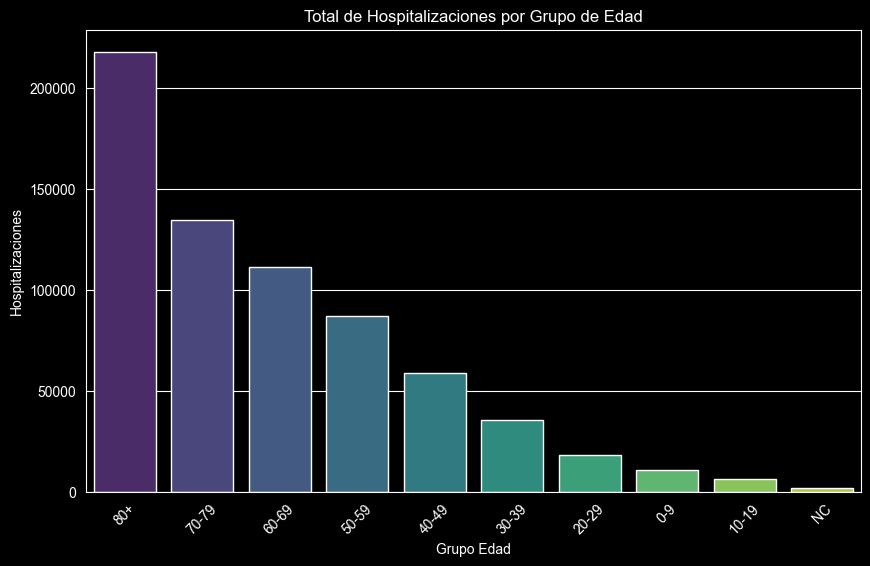

In [3]:
# Cuál fue el grupo de edad con más hospitalizaciones?
hosp_edad = master_df.groupby("grupo_edad")["num_hosp"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=hosp_edad, x="grupo_edad", y="num_hosp", palette="viridis")
plt.title("Total de Hospitalizaciones por Grupo de Edad")
plt.xlabel("Grupo Edad")
plt.ylabel("Hospitalizaciones")
plt.xticks(rotation=45)
plt.savefig(FIGURES_DIR / "total_hospitalizaciones.png")
plt.show()

En este grafico podemos visualizar que las taxas más altas de hospitalizaciones estaba acima de 50 años.
Las personas de 80+ son el grupo con la taxa de hospitalizaciones más altas.


Siguiente análisis es el de Correlación: ¿Hospitalizaciones vs UCIs vs Defunciones?
Ese análisis es vital para la IA saber si cuando suben los casos, las muertes suben proporcionalmente después de "X" dias.

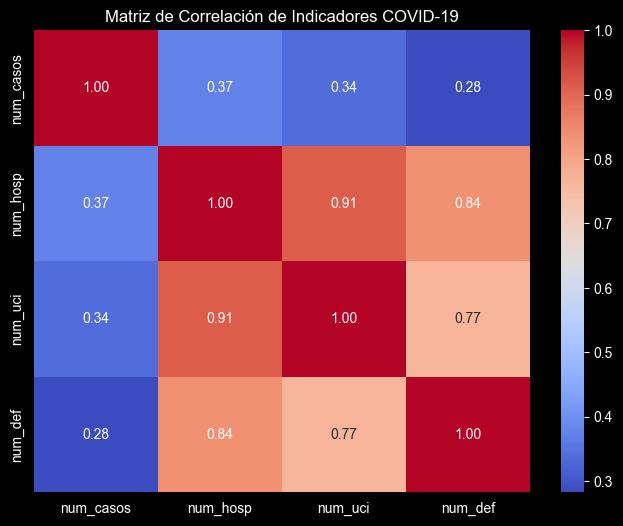

In [4]:
# Mapa de calor de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df_daily[["num_casos", "num_hosp", "num_uci", "num_def"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Indicadores COVID-19")
plt.savefig(FIGURES_DIR / "matrix_covid_indicadores.png")
plt.show()

Análisis Geoespacial (Mapa de España)
Como en los datos tenemos las provincias, esto es lo que mejor quedará en Streamlit

In [5]:
# Top 10 provincias con mas defunciones acumuladas
top_provincias = df_daily.groupby("provincia_iso")["num_def"].sum().nlargest(10).reset_index()

fig = px.bar(top_provincias, x= "provincia_iso", y="num_def", color="num_def", title = "Top 10 Provincias por Número de Defunciones")
fig.show()

Grafico de analisis geoespacial apreciamos que las provincias con mayores indices de Defunciones fueron Madrid y Barcelona, con mucha diferencia respecto a las demas.